In [7]:
!pip install mlflow dagshub

In [8]:
import os
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import mlflow
import mlflow.tensorflow

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

In [9]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("dagshub_token")

In [10]:
import mlflow
import os

DAGSHUB_USERNAME = "Aryanupadhyay23"
DAGSHUB_REPO = "Emotion-Detection-Deep-Learning"

MLFLOW_TRACKING_URI = f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = secret_value_0

In [11]:
mlflow.set_experiment("RAF_DB_Emotion_ConvNeXtTiny")

mlflow.start_run(run_name="convnext_tiny_training")

mlflow.set_tags({
    "project":"Emotion-Detection-Deep-Learning",
    "github_user":"Aryanupadhyay23",
    "model":"ConvNeXtTiny",
    "framework":"TensorFlow"
})

2026/03/07 01:44:33 INFO mlflow.tracking.fluent: Experiment with name 'RAF_DB_Emotion_ConvNeXtTiny' does not exist. Creating a new experiment.


In [12]:
DATASET_PATH = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET"

TRAIN_DIR = os.path.join(DATASET_PATH,"train")
TEST_DIR = os.path.join(DATASET_PATH,"test")

OUTPUT_DIR = "/kaggle/working/convnext_tiny_results"
os.makedirs(OUTPUT_DIR,exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100

EMOTIONS = ['Surprise','Fear','Disgust','Happy','Sad','Anger','Neutral']
NUM_CLASSES = len(EMOTIONS)

mlflow.log_params({
    "model_name":"ConvNeXtTiny",
    "image_size":IMG_SIZE,
    "batch_size":BATCH_SIZE,
    "epochs":EPOCHS,
    "num_classes":NUM_CLASSES
})

In [13]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="categorical",
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode="categorical",
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 12271 files belonging to 7 classes.


I0000 00:00:1772847889.209944      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 3068 files belonging to 7 classes.


In [14]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
])

train_ds = train_ds.map(
    lambda x,y:(data_aug(x),y),
    num_parallel_calls=AUTOTUNE
)

mlflow.log_params({
    "flip":True,
    "rotation":0.1,
    "zoom":0.1,
    "contrast":0.2
})

In [15]:
labels=[]

for _,y in train_ds.unbatch():
    labels.append(np.argmax(y.numpy()))

labels=np.array(labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights=dict(enumerate(weights))

print(class_weights)

mlflow.log_param("class_weights",str(class_weights))

{0: np.float64(1.3589147286821706), 1: np.float64(6.238434163701068), 2: np.float64(2.4449093444909344), 3: np.float64(0.3673512154233026), 4: np.float64(0.884460141271443), 5: np.float64(2.4865248226950354), 6: np.float64(0.6945324881141046)}


'{0: np.float64(1.3589147286821706), 1: np.float64(6.238434163701068), 2: np.float64(2.4449093444909344), 3: np.float64(0.3673512154233026), 4: np.float64(0.884460141271443), 5: np.float64(2.4865248226950354), 6: np.float64(0.6945324881141046)}'

In [16]:
base_model = keras.applications.ConvNeXtTiny(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE,IMG_SIZE,3)
)

base_model.trainable=True

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [17]:
inputs = keras.Input(shape=(IMG_SIZE,IMG_SIZE,3))

x = keras.ops.cast(inputs,"float32")
x = keras.applications.convnext.preprocess_input(x)

x = base_model(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(512,activation="gelu")(x)

x = layers.Dropout(0.5)(x)

x = layers.Dense(128,activation="gelu")(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES,activation="softmax")(x)

model = keras.Model(inputs,outputs)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast (Cast)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,283,495 (107.89 MB)

 Trainable params: 28,281,959 (107.89 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [18]:
ARCH_PATH = os.path.join(OUTPUT_DIR,"architecture.png")

tf.keras.utils.plot_model(
    model,
    to_file=ARCH_PATH,
    show_shapes=True,
    show_layer_names=True
)

mlflow.log_artifact(ARCH_PATH)

In [19]:
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

optimizer = keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

mlflow.log_params({
    "optimizer":"Adam",
    "learning_rate":1e-4,
    "label_smoothing":0.1
})

In [20]:
callbacks=[

keras.callbacks.ModelCheckpoint(
    os.path.join(OUTPUT_DIR,"best_model.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
),

keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True
),

keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
),

keras.callbacks.CSVLogger(
    os.path.join(OUTPUT_DIR,"training_log.csv")
)

]

In [21]:
start=time.time()

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

training_time=time.time()-start

mlflow.log_metric("training_time_seconds",training_time)

Epoch 1/100


I0000 00:00:1772847999.706555     180 service.cc:152] XLA service 0x7f329c0253d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772847999.706612     180 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772848005.599793     180 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-07 01:46:50.458399: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 01:46:50.635394: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 01:46:50.881413: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

383/384 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.2571 - loss: 2.2050

2026-03-07 01:49:36.722377: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 01:49:36.898594: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 01:49:37.130158: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 01:49:37.325589: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.2573 - loss: 2.2044
Epoch 1: val_accuracy improved from -inf to 0.50261, saving model to /kaggle/working/convnext_tiny_results/best_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 243s 479ms/step - accuracy: 0.2576 - loss: 2.2038 - val_accuracy: 0.5026 - val_loss: 1.4491 - learning_rate: 1.0000e-04
Epoch 2/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.4955 - loss: 1.6026
Epoch 2: val_accuracy improved from 0.50261 to 0.65156, saving model to /kaggle/working/convnext_tiny_results/best_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 149s 387ms/step - accuracy: 0.4956 - loss: 1.6024 - val_accuracy: 0.6516 - val_loss: 1.2299 - learning_rate: 1.0000e-04
Epoch 3/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.5837 - loss: 1.3954
Epoch 3: val_accuracy improved from 0.65156 to 0.71154, saving model to /kaggle/working/convnext_tiny_results/best_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 150s 388ms/step - accuracy: 0.5838 - los

In [22]:
for i in range(len(history.history["accuracy"])):

    mlflow.log_metric("train_accuracy",history.history["accuracy"][i],step=i)
    mlflow.log_metric("val_accuracy",history.history["val_accuracy"][i],step=i)
    mlflow.log_metric("train_loss",history.history["loss"][i],step=i)
    mlflow.log_metric("val_loss",history.history["val_loss"][i],step=i)

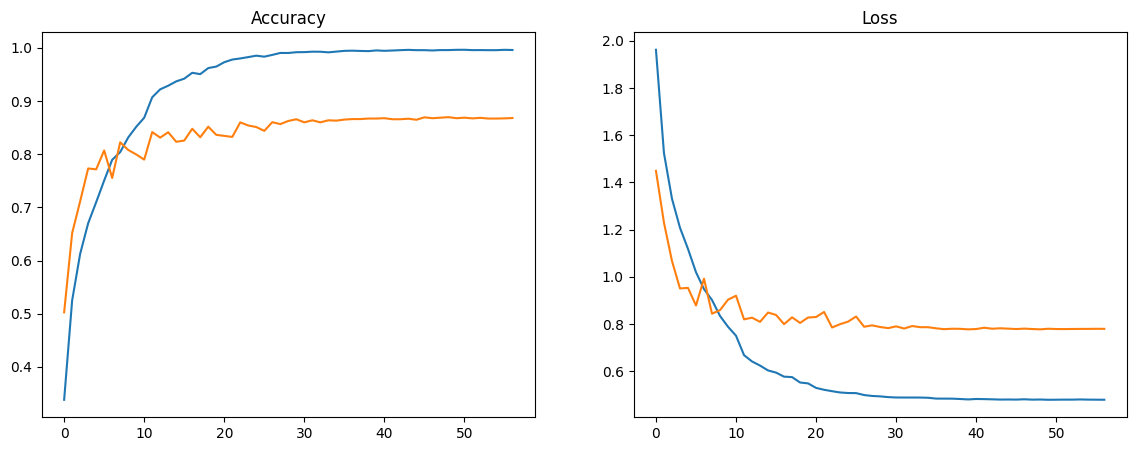

In [23]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")

curve_path=os.path.join(OUTPUT_DIR,"training_curves.png")

plt.savefig(curve_path)

mlflow.log_artifact(curve_path)

plt.show()

In [24]:
best_model = keras.models.load_model(
    os.path.join(OUTPUT_DIR,"best_model.keras")
)

mlflow.tensorflow.log_model(best_model,"model")

2026/03/07 04:12:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/07 04:12:13 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/03/07 04:12:42 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpm7z2u7bu/model, flavor: tensorflow). Fall back to return ['tensorflow==2.19.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


In [25]:
y_true=[]
y_pred=[]
y_prob=[]

for x,y in test_ds:

    preds=best_model.predict(x)

    y_true.extend(np.argmax(y.numpy(),axis=1))
    y_pred.extend(np.argmax(preds,axis=1))
    y_prob.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [26]:
acc=accuracy_score(y_true,y_pred)

print("Test Accuracy:",acc)

mlflow.log_metric("test_accuracy",acc)

Test Accuracy: 0.8696219035202086


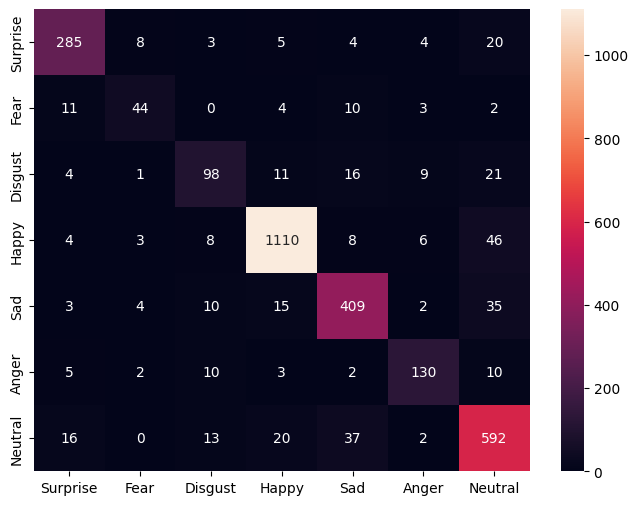

In [27]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=EMOTIONS,
    yticklabels=EMOTIONS
)

cm_path=os.path.join(OUTPUT_DIR,"confusion_matrix.png")

plt.savefig(cm_path)

mlflow.log_artifact(cm_path)

plt.show()

In [28]:
report = classification_report(
    y_true,
    y_pred,
    target_names=EMOTIONS
)

print(report)

report_path=os.path.join(OUTPUT_DIR,"classification_report.txt")

with open(report_path,"w") as f:
    f.write(report)

mlflow.log_artifact(report_path)

              precision    recall  f1-score   support

    Surprise       0.87      0.87      0.87       329
        Fear       0.71      0.59      0.65        74
     Disgust       0.69      0.61      0.65       160
       Happy       0.95      0.94      0.94      1185
         Sad       0.84      0.86      0.85       478
       Anger       0.83      0.80      0.82       162
     Neutral       0.82      0.87      0.84       680

    accuracy                           0.87      3068
   macro avg       0.82      0.79      0.80      3068
weighted avg       0.87      0.87      0.87      3068



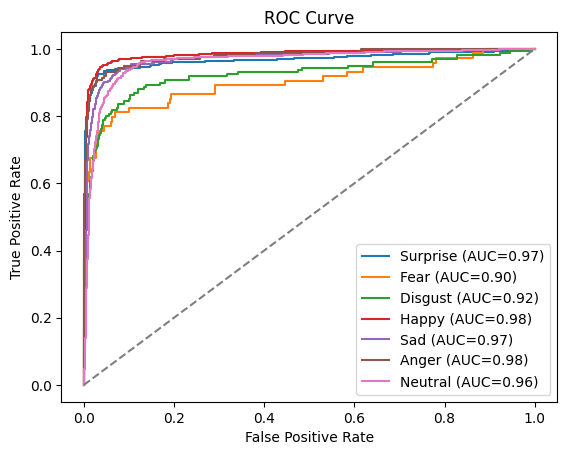

In [29]:
y_true_bin = label_binarize(y_true,classes=range(NUM_CLASSES))
y_prob=np.array(y_prob)

plt.figure()

for i in range(NUM_CLASSES):

    fpr,tpr,_ = roc_curve(y_true_bin[:,i],y_prob[:,i])
    roc_auc = auc(fpr,tpr)

    mlflow.log_metric(f"roc_auc_{EMOTIONS[i]}",roc_auc)

    plt.plot(fpr,tpr,label=f"{EMOTIONS[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

roc_path=os.path.join(OUTPUT_DIR,"roc_curve.png")

plt.savefig(roc_path)

mlflow.log_artifact(roc_path)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


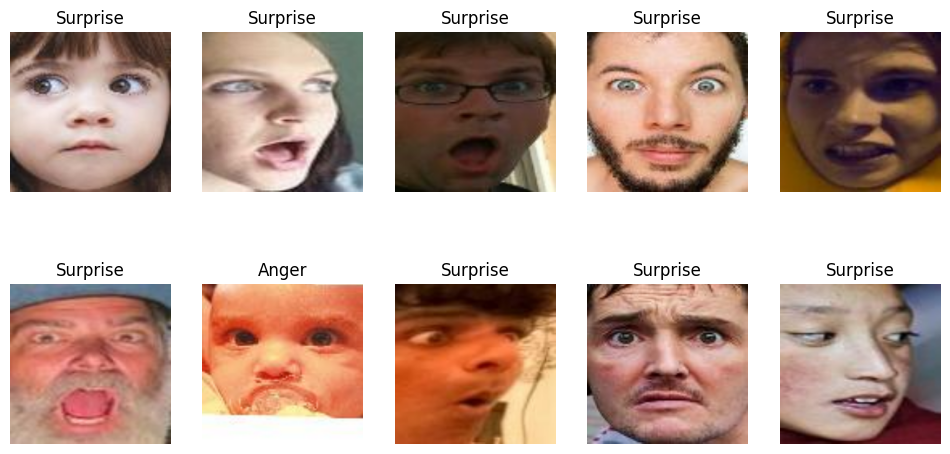

In [30]:
images,labels = next(iter(test_ds))

preds = best_model.predict(images[:10])

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i].numpy().astype("uint8"))

    plt.title(EMOTIONS[np.argmax(preds[i])])

    plt.axis("off")

sample_path=os.path.join(OUTPUT_DIR,"sample_predictions.png")

plt.savefig(sample_path)

mlflow.log_artifact(sample_path)

plt.show()

In [31]:
mlflow.end_run()

🏃 View run convnext_tiny_training at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/10/runs/8353fc9151124acc828b2f29153636bd
🧪 View experiment at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/10
